<!-- ARTHASAATHI-PROVENANCE -->
> ## ⚠️ This notebook is demo evidence, not the running system
>
> The logic below was migrated to **`ml/src/councils/cashflow/income_projection.py`** and that module is what the application actually executes.
>
> **Role in the system:** Cashflow Council -> Income Projection Agent
>
> This notebook is preserved because its stored outputs are the record of the original analysis. **Editing the cells below will not change the system's behaviour** — change the module and its tests instead.
>
> Tests for this logic live under `tests/`, and every agent is covered by the cross-cutting contract suite in `tests/common/test_contracts.py`.


# 📊 Rule-Based Financial Forecasting with Holt-Winters
### Occupation-aware income & expense prediction — Min / Avg / Max scenarios

**Methodology:**
- **Rule layer** — occupation + season adjustment factors per category  
- **Holt-Winters layer** — triple exponential smoothing on seasonal expense categories (Utilities, Groceries, Fuel/Transport)  
- **Scenario layer** — pessimistic / expected / optimistic cashflow bands


In [1]:
# ============================================================
#  USER INPUTS  —  edit these to personalise the forecast
# ============================================================

occupation        = "teacher"
is_vacation_month = True          # True = school holiday month

income = {
    "Salary":        50_000,
    "Rent Income":    5_000,
    "Interest":       1_000,
    "Pension":            0,
    "Freelance/Gig":      0,
    "Business":           0,
    "Investment":         0,
    "Other Income":       0,
}

expenses = {
    "Rent/EMI":      15_000,
    "Insurance":      1_000,
    "Utilities":      2_000,
    "Groceries":      8_000,
    "Fuel/Transport": 3_000,
    "Shopping":       2_000,
    "Entertainment":  1_000,
    "Travel":             0,
    "Medical":        1_000,
    "Other Expense":  1_000,
}


In [2]:
# ============================================================
#  CATEGORY TAGS
# ============================================================

INCOME_CATEGORIES = {
    "Salary":        "recurring",
    "Rent Income":   "recurring",
    "Interest":      "recurring",
    "Pension":       "recurring",
    "Freelance/Gig": "variable",
    "Business":      "irregular",
    "Investment":    "variable",
    "Other Income":  "irregular",
}

EXPENSE_CATEGORIES = {
    "Rent/EMI":      "recurring",
    "Insurance":     "recurring",
    "Utilities":     "seasonal",
    "Groceries":     "seasonal",
    "Fuel/Transport":"seasonal",
    "Shopping":      "discretionary",
    "Entertainment": "discretionary",
    "Travel":        "discretionary",
    "Medical":       "irregular",
    "Other Expense": "irregular",
}

# ============================================================
#  OCCUPATION PROFILES
# ============================================================

OCC_TYPE = {
    "salaried":   {"stability": "high",   "seasonality": "low",    "variability": "low"},
    "teacher":    {"stability": "high",   "seasonality": "medium", "variability": "low"},
    "farmer":     {"stability": "low",    "seasonality": "high",   "variability": "high"},
    "gig worker": {"stability": "low",    "seasonality": "medium", "variability": "high"},
    "business":   {"stability": "medium", "seasonality": "medium", "variability": "high"},
}

occ_key     = occupation.lower()
occ_profile = next(
    (v for k, v in OCC_TYPE.items() if k in occ_key),
    {"stability": "medium", "seasonality": "medium", "variability": "medium"},
)

print(f"Occupation  : {occupation}")
print(f"Stability   : {occ_profile['stability']}")
print(f"Seasonality : {occ_profile['seasonality']}")
print(f"Variability : {occ_profile['variability']}")
print(f"Month type  : {'Vacation' if is_vacation_month else 'Normal'}")


Occupation  : teacher
Stability   : high
Seasonality : medium
Variability : low
Month type  : Vacation


In [3]:
# ============================================================
#  TEACHER-SPECIFIC ADJUSTMENT FACTORS
#  (add more occupations following the same pattern)
# ============================================================

TEACHER_RULES = {
    "income": {
        "Salary":        {"normal": 1.00, "vacation": 0.60},   # reduced during school holidays
        "Rent Income":   {"normal": 1.00, "vacation": 1.00},
        "Interest":      {"normal": 1.00, "vacation": 1.00},
        "Pension":       {"normal": 1.00, "vacation": 1.00},
        "Freelance/Gig": {"normal": 1.00, "vacation": 1.30},   # tutoring/coaching uptick
        "Business":      {"normal": 1.00, "vacation": 1.00},
        "Investment":    {"normal": 1.00, "vacation": 1.00},
        "Other Income":  {"normal": 1.00, "vacation": 1.00},
    },
    "expense": {
        "Rent/EMI":      {"normal": 1.00, "vacation": 1.00},
        "Insurance":     {"normal": 1.00, "vacation": 1.00},
        "Utilities":     {"normal": 1.00, "vacation": 1.10},   # home all day
        "Groceries":     {"normal": 1.00, "vacation": 1.15},   # meals in
        "Fuel/Transport":{"normal": 1.00, "vacation": 0.80},   # no daily commute
        "Shopping":      {"normal": 1.00, "vacation": 1.20},
        "Entertainment": {"normal": 1.00, "vacation": 1.50},
        "Travel":        {"normal": 1.00, "vacation": 2.00},   # holiday trips
        "Medical":       {"normal": 1.00, "vacation": 1.00},
        "Other Expense": {"normal": 1.00, "vacation": 1.10},
    },
}

# Rule logic descriptions (shown in report)
INCOME_RULE_LOGIC = {
    "Salary":        "recurring × vacation 0.6  — reduced pay during school holidays",
    "Rent Income":   "recurring × 1.0           — unaffected by school calendar",
    "Interest":      "recurring × 1.0           — fixed deposit / bond, no seasonality",
    "Pension":       "recurring × 1.0           — fixed disbursement",
    "Freelance/Gig": "variable  × vacation 1.3  — free time → tutoring / coaching uptick",
    "Business":      "irregular × 1.0           — no occupation-specific rule",
    "Investment":    "variable  × 1.0           — market-driven, no seasonal rule",
    "Other Income":  "irregular × 1.0           — no occupation-specific rule",
}

EXPENSE_RULE_LOGIC = {
    "Rent/EMI":      "recurring      × 1.0         — fixed obligation",
    "Insurance":     "recurring      × 1.0         — fixed premium schedule",
    "Utilities":     "seasonal       × vacation 1.1 — home usage rises  [HW model applied]",
    "Groceries":     "seasonal       × vacation 1.15— family home more  [HW model applied]",
    "Fuel/Transport":"seasonal       × vacation 0.8 — no daily commute  [HW model applied]",
    "Shopping":      "discretionary  × vacation 1.2 — leisure time → higher spend intent",
    "Entertainment": "discretionary  × vacation 1.5 — free time, outings, OTT upgrades",
    "Travel":        "discretionary  × vacation 2.0 — school holiday trips spike",
    "Medical":       "irregular      × 1.0         — unplanned, no strong seasonal signal",
    "Other Expense": "irregular      × vacation 1.1 — miscellaneous uptick",
}


In [4]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ============================================================
#  HOLT-WINTERS TRIPLE EXPONENTIAL SMOOTHING
# ============================================================

def holt_winters(series, alpha=0.3, beta=0.1, gamma=0.4, period=12, steps=3):
    """
    Additive-multiplicative Holt-Winters.
    Returns `steps` one-step-ahead forecasts beyond the series end.
    """
    n = len(series)
    assert n >= period * 2, "Need at least 2 full seasons"

    # Initialise
    L = np.mean(series[:period])
    T = (np.mean(series[period:2*period]) - np.mean(series[:period])) / period
    S = [series[i] / L for i in range(period)]

    Ls, Ts, Ss = [L], [T], S.copy()

    for t in range(period, n):
        prev_L = Ls[-1]
        new_L  = alpha * (series[t] / Ss[t - period]) + (1 - alpha) * (prev_L + Ts[-1])
        new_T  = beta  * (new_L - prev_L)              + (1 - beta)  * Ts[-1]
        new_S  = gamma * (series[t] / new_L)           + (1 - gamma) * Ss[t - period]
        Ls.append(new_L); Ts.append(new_T); Ss.append(new_S)

    forecasts = []
    for h in range(1, steps + 1):
        sp = Ss[n - period + (h - 1) % period]
        forecasts.append((Ls[-1] + Ts[-1] * h) * sp)

    return forecasts, Ls, Ts, Ss


# ── Seeded population history generator ─────────────────────
def gen_population_history(base, amplitude, noise_std, n=36, seed=42):
    """
    Generate a realistic 3-year monthly series for a population benchmark.
    Uses a fixed seed for reproducibility.
    """
    rng = np.random.default_rng(seed)
    t   = np.arange(n)
    seasonal = amplitude * np.sin(2 * np.pi * t / 12)
    noise    = rng.normal(0, noise_std, n)
    return np.maximum(0, base + seasonal + noise)


# Population benchmark configs for seasonal categories
HW_POPULATION_CFG = {
    "Utilities":       {"base": 2200, "amplitude": 500,  "noise_std": 200},
    "Groceries":       {"base": 7500, "amplitude": 1000, "noise_std": 400},
    "Fuel/Transport":  {"base": 3200, "amplitude": 700,  "noise_std": 300},
}


def hw_forecast_for_category(cat_name, current_val, steps=3):
    """
    1. Generate population history with HW_POPULATION_CFG.
    2. Run Holt-Winters → next-period population forecast.
    3. Compute user's personalised ratio = current_val / pop_avg_forecast.
    4. Scale the 3rd-step forecast by that ratio.
    Returns dict with min / avg / max and diagnostic info.
    """
    cfg = HW_POPULATION_CFG.get(cat_name)
    if cfg is None:
        return None

    pop_history     = gen_population_history(**cfg)
    pop_forecasts, *_ = holt_winters(pop_history, steps=steps)
    pop_avg_next    = pop_forecasts[0]           # 1-month-ahead population benchmark

    ratio = current_val / pop_avg_next if pop_avg_next > 0 else 1.0
    personalised_forecast = pop_forecasts[2] * ratio   # 3-month-ahead, scaled

    return {
        "min":     round(personalised_forecast * 0.85),
        "avg":     round(personalised_forecast),
        "max":     round(personalised_forecast * 1.18),
        "pop_avg": round(pop_avg_next),
        "ratio":   round(ratio, 3),
        "logic":   (
            f"Population HW avg ≈ ₹{pop_avg_next:,.0f}  |  "
            f"Your ratio = {ratio*100:.1f}% of pop avg  |  "
            f"Scaled forecast = ₹{personalised_forecast:,.0f}"
        ),
    }


print("Holt-Winters engine ready ✓")


Holt-Winters engine ready ✓


In [5]:
# ============================================================
#  FORECAST ENGINE
#  — Applies rules + optional HW layer, computes min/avg/max
# ============================================================

# Variability bands by category type (used when HW not applicable)
VAR_BANDS = {
    "recurring":     0.03,
    "variable":      0.12,
    "seasonal":      0.15,
    "discretionary": 0.18,
    "irregular":     0.20,
}

season = "vacation" if is_vacation_month else "normal"


def forecast_item(item_type, name, base_val):
    """
    item_type : 'income' | 'expense'
    Returns a dict with all forecast diagnostics.
    """
    rule_map  = TEACHER_RULES[item_type]
    factor    = rule_map.get(name, {}).get(season, 1.0)
    rule_pred = round(base_val * factor)

    cat_map = INCOME_CATEGORIES if item_type == "income" else EXPENSE_CATEGORIES
    cat     = cat_map.get(name, "irregular")

    # ── Apply Holt-Winters for seasonal expense categories ──
    hw = None
    if item_type == "expense" and cat == "seasonal":
        hw = hw_forecast_for_category(name, base_val)

    if hw:
        avg    = round((rule_pred + hw["avg"]) / 2)
        min_v  = round((rule_pred * 0.92 + hw["min"]) / 2)
        max_v  = round((rule_pred * 1.08 + hw["max"]) / 2)
        method = "HW + Rule"
    else:
        band  = VAR_BANDS.get(cat, 0.10)
        avg   = rule_pred
        min_v = round(rule_pred * (1 - band))
        max_v = round(rule_pred * (1 + band))
        method = "Rule only"

    return {
        "name":       name,
        "base_val":   base_val,
        "category":   cat,
        "factor":     factor,
        "rule_pred":  rule_pred,
        "method":     method,
        "min":        min_v,
        "avg":        avg,
        "max":        max_v,
        "hw":         hw,
    }


income_forecast  = [forecast_item("income",  k, v) for k, v in income.items()]
expense_forecast = [forecast_item("expense", k, v) for k, v in expenses.items()]

print("Forecast complete ✓")
print(f"  Income  rows : {len(income_forecast)}")
print(f"  Expense rows : {len(expense_forecast)}")


Forecast complete ✓
  Income  rows : 8
  Expense rows : 10


In [6]:
import pandas as pd

# ============================================================
#  SUMMARY TABLES
# ============================================================

def rows_to_df(forecast_list, rule_logic_map):
    records = []
    for r in forecast_list:
        if r["base_val"] == 0 and r["avg"] == 0:
            continue
        records.append({
            "Category":   r["name"],
            "Type":       r["category"],
            "Base (₹)":  r["base_val"],
            "Factor":     r["factor"],
            "Method":     r["method"],
            "Min (₹)":   r["min"],
            "Avg (₹)":   r["avg"],
            "Max (₹)":   r["max"],
            "Rule Logic": rule_logic_map.get(r["name"], ""),
        })
    return pd.DataFrame(records)

df_income  = rows_to_df(income_forecast,  INCOME_RULE_LOGIC)
df_expense = rows_to_df(expense_forecast, EXPENSE_RULE_LOGIC)

print("=" * 60)
print("  PREDICTED INCOME")
print("=" * 60)
display(df_income[["Category","Type","Base (₹)","Factor","Method","Min (₹)","Avg (₹)","Max (₹)"]].set_index("Category"))

print()
print("=" * 60)
print("  PREDICTED EXPENSES")
print("=" * 60)
display(df_expense[["Category","Type","Base (₹)","Factor","Method","Min (₹)","Avg (₹)","Max (₹)"]].set_index("Category"))


  PREDICTED INCOME


,Type,Base (₹),Factor,Method,Min (₹),Avg (₹),Max (₹)
Category,,,,,,,
Salary,recurring,50000,0.6,Rule only,29100,30000,30900
Rent Income,recurring,5000,1.0,Rule only,4850,5000,5150
Interest,recurring,1000,1.0,Rule only,970,1000,1030



  PREDICTED EXPENSES


,Type,Base (₹),Factor,Method,Min (₹),Avg (₹),Max (₹)
Category,,,,,,,
Rent/EMI,recurring,15000,1.00,Rule only,14550,15000,15450
Insurance,recurring,1000,1.00,Rule only,970,1000,1030
Utilities,seasonal,2000,1.10,HW + Rule,2066,2339,2650
Groceries,seasonal,8000,1.15,HW + Rule,8111,9164,10352
Fuel/Transport,seasonal,3000,0.80,HW + Rule,2676,3050,3478
Shopping,discretionary,2000,1.20,Rule only,1968,2400,2832
Entertainment,discretionary,1000,1.50,Rule only,1230,1500,1770
Medical,irregular,1000,1.00,Rule only,800,1000,1200
Other Expense,irregular,1000,1.10,Rule only,880,1100,1320


In [7]:
# ============================================================
#  THREE-SCENARIO CASHFLOW SUMMARY
# ============================================================

total_inc_min = sum(r["min"] for r in income_forecast)
total_inc_avg = sum(r["avg"] for r in income_forecast)
total_inc_max = sum(r["max"] for r in income_forecast)

total_exp_min = sum(r["min"] for r in expense_forecast)
total_exp_avg = sum(r["avg"] for r in expense_forecast)
total_exp_max = sum(r["max"] for r in expense_forecast)

net_pessimistic = total_inc_min - total_exp_max   # worst case
net_expected    = total_inc_avg - total_exp_avg   # blended
net_optimistic  = total_inc_max - total_exp_min   # best case

savings_rate = round(net_expected / total_inc_avg * 100, 1) if total_inc_avg > 0 else 0

summary = pd.DataFrame({
    "Scenario":      ["Pessimistic (min)", "Expected (avg)", "Optimistic (max)"],
    "Total Income":  [total_inc_min, total_inc_avg, total_inc_max],
    "Total Expense": [total_exp_max, total_exp_avg, total_exp_min],
    "Net Cashflow":  [net_pessimistic, net_expected, net_optimistic],
}).set_index("Scenario")

print("=" * 60)
print("  CASHFLOW SCENARIOS")
print("=" * 60)
display(summary.style.format("₹{:,.0f}").applymap(
    lambda v: "color: green" if v >= 0 else "color: red",
    subset=["Net Cashflow"]
))

print(f"\nSavings rate (expected) : {savings_rate}% of predicted income")


  CASHFLOW SCENARIOS


,Total Income,Total Expense,Net Cashflow
Scenario,,,
Pessimistic (min),"₹34,920","₹40,082","₹-5,162"
Expected (avg),"₹36,000","₹36,553",₹-553
Optimistic (max),"₹37,080","₹33,251","₹3,829"



Savings rate (expected) : -1.5% of predicted income


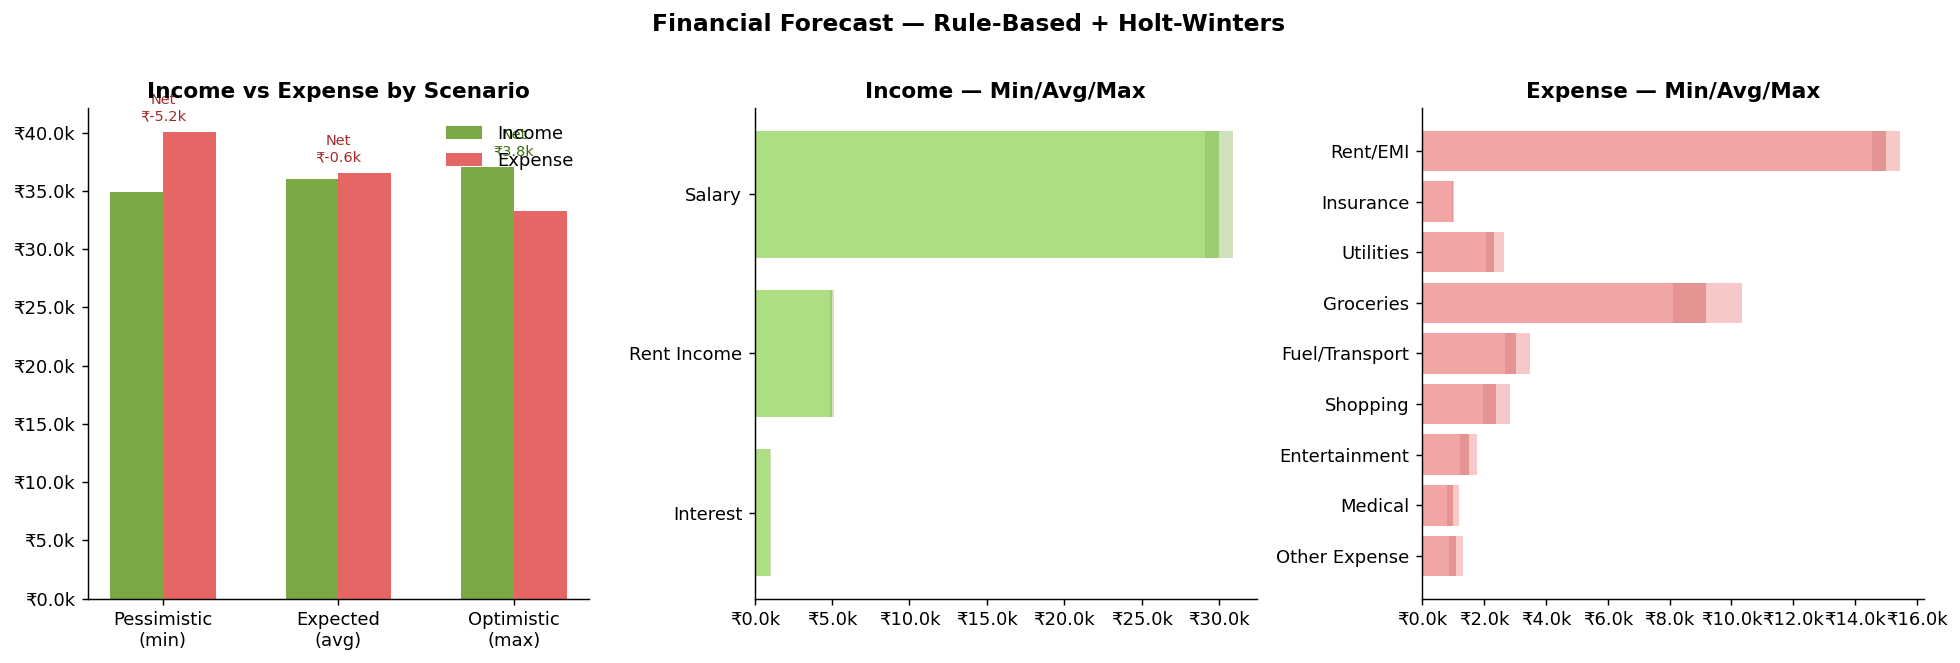

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ============================================================
#  VISUALISATION
#  1. Scenario bar chart  (income vs expense, 3 scenarios)
#  2. Category breakdown  (income & expense avg bars)
#  3. Holt-Winters history + forecast for seasonal categories
# ============================================================

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

INR = lambda x: f"₹{x/1000:.1f}k"

# ── 1. Scenario bar chart ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Financial Forecast — Rule-Based + Holt-Winters", fontsize=13, fontweight="bold", y=1.01)

ax = axes[0]
scenarios    = ["Pessimistic\n(min)", "Expected\n(avg)", "Optimistic\n(max)"]
income_vals  = [total_inc_min, total_inc_avg, total_inc_max]
expense_vals = [total_exp_max, total_exp_avg, total_exp_min]
net_vals     = [net_pessimistic, net_expected, net_optimistic]

x = np.arange(3)
w = 0.3
ax.bar(x - w/2, income_vals,  w, color="#639922", label="Income",  alpha=0.85)
ax.bar(x + w/2, expense_vals, w, color="#E24B4A", label="Expense", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(scenarios)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: INR(v)))
ax.set_title("Income vs Expense by Scenario", fontweight="bold")
ax.legend(frameon=False)
for i, (iv, ev, nv) in enumerate(zip(income_vals, expense_vals, net_vals)):
    col = "#3B6D11" if nv >= 0 else "#A32D2D"
    ax.annotate(f"Net\n{INR(nv)}", (i, max(iv, ev) + 1000), ha="center", fontsize=8, color=col)

# ── 2. Category breakdowns ────────────────────────────────
ax2 = axes[1]
df_inc_plot = df_income[df_income["Avg (₹)"] > 0].copy()
ax2.barh(df_inc_plot["Category"], df_inc_plot["Avg (₹)"], color="#9FD96B", alpha=0.85)
ax2.barh(df_inc_plot["Category"], df_inc_plot["Max (₹)"] - df_inc_plot["Avg (₹)"],
         left=df_inc_plot["Avg (₹)"], color="#639922", alpha=0.3)
ax2.barh(df_inc_plot["Category"], df_inc_plot["Avg (₹)"] - df_inc_plot["Min (₹)"],
         left=df_inc_plot["Min (₹)"], color="#3B6D11", alpha=0.15)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: INR(v)))
ax2.set_title("Income — Min/Avg/Max", fontweight="bold")
ax2.invert_yaxis()

ax3 = axes[2]
df_exp_plot = df_expense[df_expense["Avg (₹)"] > 0].copy()
ax3.barh(df_exp_plot["Category"], df_exp_plot["Avg (₹)"], color="#F09595", alpha=0.85)
ax3.barh(df_exp_plot["Category"], df_exp_plot["Max (₹)"] - df_exp_plot["Avg (₹)"],
         left=df_exp_plot["Avg (₹)"], color="#E24B4A", alpha=0.3)
ax3.barh(df_exp_plot["Category"], df_exp_plot["Avg (₹)"] - df_exp_plot["Min (₹)"],
         left=df_exp_plot["Min (₹)"], color="#A32D2D", alpha=0.15)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: INR(v)))
ax3.set_title("Expense — Min/Avg/Max", fontweight="bold")
ax3.invert_yaxis()

plt.tight_layout()
plt.show()


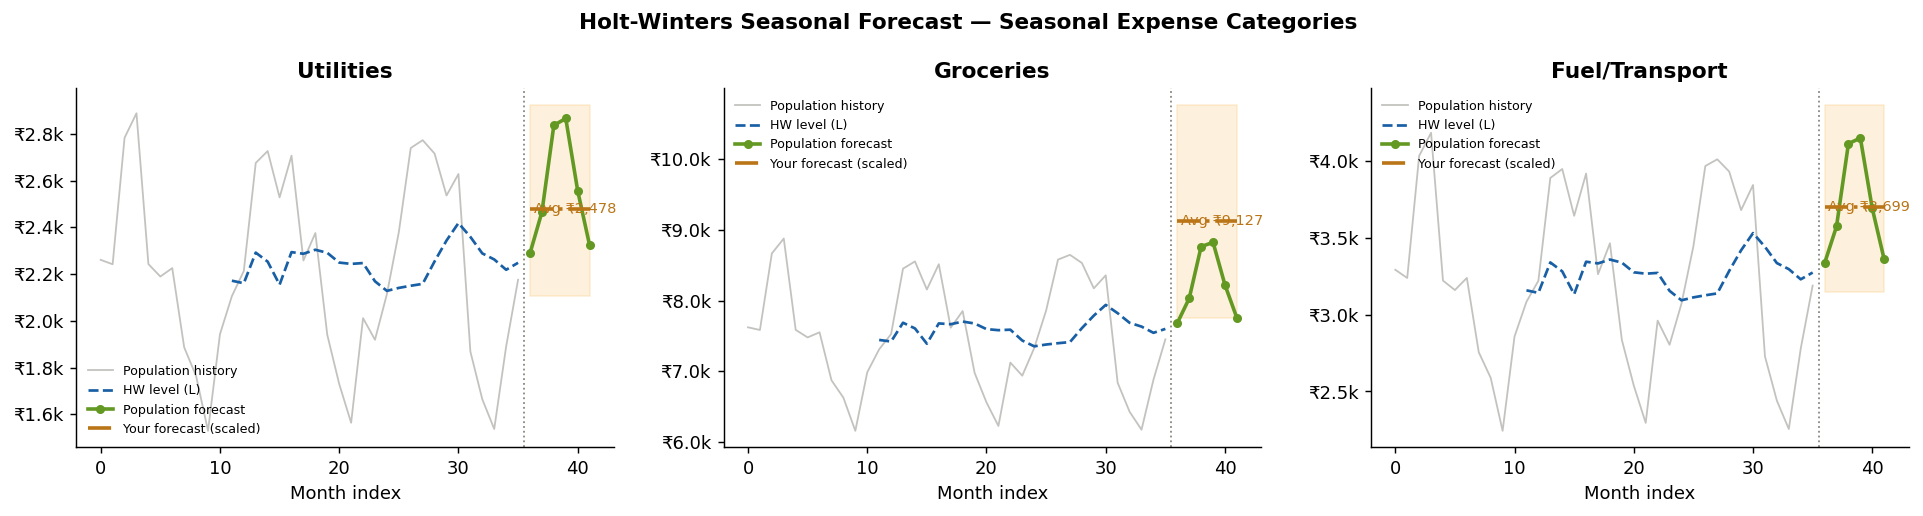

In [12]:
# ============================================================
#  HOLT-WINTERS — Population history + personalised forecast
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle("Holt-Winters Seasonal Forecast — Seasonal Expense Categories", fontsize=12, fontweight="bold")

for i, (cat_name, cfg) in enumerate(HW_POPULATION_CFG.items()):
    ax = axes[i]
    pop_hist = gen_population_history(**cfg)
    forecasts, Ls, Ts, Ss = holt_winters(pop_hist, steps=6)

    n = len(pop_hist)
    t_hist = np.arange(n)
    t_fore = np.arange(n, n + 6)

    ax.plot(t_hist, pop_hist, color="#888780", alpha=0.5, linewidth=1, label="Population history")
    # `Ls` is shorter than `pop_hist` (initial state + updates); align indices by slicing `t_hist`
    ax.plot(t_hist[len(t_hist) - len(Ls):], Ls, color="#185FA5", linewidth=1.5, linestyle="--", label="HW level (L)")
    ax.plot(t_fore, forecasts, color="#639922", linewidth=2, marker="o", markersize=4, label="Population forecast")

    # User personalised forecast band
    hw_res  = hw_forecast_for_category(cat_name, expenses.get(cat_name, 0))
    user_f  = np.array([hw_res["avg"]] * 6)
    user_lo = np.array([hw_res["min"]] * 6)
    user_hi = np.array([hw_res["max"]] * 6)

    ax.fill_between(t_fore, user_lo, user_hi, color="#FAC775", alpha=0.25)
    ax.plot(t_fore, user_f, color="#BA7517", linewidth=2, linestyle="-.", label="Your forecast (scaled)")
    ax.axvline(n - 0.5, color="#888780", linestyle=":", linewidth=1)
    ax.set_title(cat_name, fontweight="bold")
    ax.set_xlabel("Month index")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"₹{v/1000:.1f}k"))
    ax.legend(fontsize=7, frameon=False)
    ax.text(n + 0.3, hw_res["avg"], f"Avg ₹{hw_res['avg']:,}", fontsize=8, color="#BA7517", va="center")

plt.tight_layout()
plt.show()


In [13]:
# ============================================================
#  DETAILED RULE LOGIC REPORT
# ============================================================

print(f"Occupation : {occupation}  |  Month type : {'Vacation' if is_vacation_month else 'Normal'}")
print(f"Stability={occ_profile['stability']}  Seasonality={occ_profile['seasonality']}  Variability={occ_profile['variability']}")

print("\n" + "=" * 70)
print("  INCOME RULE LOGIC")
print("=" * 70)
for r in income_forecast:
    if r["base_val"] == 0:
        continue
    hw_note = ""
    if r["hw"]:
        hw_note = f"\n          HW: {r['hw']['logic']}"
    print(f"  {r['name']:<18} [{r['category']:<11}]  factor={r['factor']:.2f}x  method={r['method']}")
    print(f"          {INCOME_RULE_LOGIC.get(r['name'], '')}{hw_note}")
    print(f"          Min=₹{r['min']:,}  Avg=₹{r['avg']:,}  Max=₹{r['max']:,}")
    print()

print("=" * 70)
print("  EXPENSE RULE LOGIC")
print("=" * 70)
for r in expense_forecast:
    hw_note = ""
    if r["hw"]:
        hw_note = f"\n          HW: {r['hw']['logic']}"
    print(f"  {r['name']:<18} [{r['category']:<13}]  factor={r['factor']:.2f}x  method={r['method']}")
    print(f"          {EXPENSE_RULE_LOGIC.get(r['name'], '')}{hw_note}")
    print(f"          Min=₹{r['min']:,}  Avg=₹{r['avg']:,}  Max=₹{r['max']:,}")
    print()

print("=" * 70)
print("  CASHFLOW SUMMARY")
print("=" * 70)
print(f"  Pessimistic : Income ₹{total_inc_min:,}  –  Expense ₹{total_exp_max:,}  =  Net ₹{net_pessimistic:,}")
print(f"  Expected    : Income ₹{total_inc_avg:,}  –  Expense ₹{total_exp_avg:,}  =  Net ₹{net_expected:,}")
print(f"  Optimistic  : Income ₹{total_inc_max:,}  –  Expense ₹{total_exp_min:,}  =  Net ₹{net_optimistic:,}")
print(f"\n  Savings rate (expected) : {savings_rate}%")


Occupation : teacher  |  Month type : Vacation
Stability=high  Seasonality=medium  Variability=low

  INCOME RULE LOGIC
  Salary             [recurring  ]  factor=0.60x  method=Rule only
          recurring × vacation 0.6  — reduced pay during school holidays
          Min=₹29,100  Avg=₹30,000  Max=₹30,900

  Rent Income        [recurring  ]  factor=1.00x  method=Rule only
          recurring × 1.0           — unaffected by school calendar
          Min=₹4,850  Avg=₹5,000  Max=₹5,150

  Interest           [recurring  ]  factor=1.00x  method=Rule only
          recurring × 1.0           — fixed deposit / bond, no seasonality
          Min=₹970  Avg=₹1,000  Max=₹1,030

  EXPENSE RULE LOGIC
  Rent/EMI           [recurring    ]  factor=1.00x  method=Rule only
          recurring      × 1.0         — fixed obligation
          Min=₹14,550  Avg=₹15,000  Max=₹15,450

  Insurance          [recurring    ]  factor=1.00x  method=Rule only
          recurring      × 1.0         — fixed premium sch